# GP-HMM: Streaming Inference Demo

This notebook demonstrates the streaming HMM with **Gaussian Process (GP) emission models**.
Unlike parametric models (Gaussian, AR), the GP model maintains a buffer of observed
(input, output) pairs per regime, and uses them to compute posterior predictive distributions.

**Model:**
$$
\begin{aligned}
    p(s_t \mid s_{t-1}) &= \pi_{s_t,\,s_{t-1}} \quad\text{(known)}\\
    y_t \mid s_t{=}k &\sim \mathcal{GP}(0, K^{(k)}(\cdot, \cdot)) + \varepsilon_t,
    \quad \varepsilon_t \sim \mathcal{N}(0,\, \sigma^2)
\end{aligned}
$$

The GP posterior predictive provides multi-step-ahead forecasts where:
- The **mean** oscillates according to the learned pattern
- The **predictive variance** increases with forecast horizon

In [26]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import seaborn as sns
from streaming_hmm import (
    run_gp_streaming_hmm,
    init_gp_particles,
    gaussian_kernel,
    periodic_kernel,
    make_gp_forecast_fn,
    build_weights,
    _gp_predictive,
)

In [27]:
# Configure matplotlib
%config InlineBackend.figure_format = "retina"
# %config InlineBackend.figure_format = "png"
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.spines.top"] = False
plt.rcParams["font.size"] = 12
# plt.rcParams["figure.figsize"] = (10, 4.0)
plt.rcParams["figure.figsize"] = (7, 3.0)
plt.rcParams["text.usetex"] = False
plt.rcParams["font.family"] = "serif"

sns.set_palette("colorblind")
colors = sns.color_palette()

## Mathematical Framework

### Regime-Switching State-Space Model

We model observations $y_t \in \mathbb{R}$ arising from a latent discrete regime $s_t \in \{1,\ldots,K\}$ that evolves according to a Markov chain:

$$
\begin{aligned}
s_t \mid s_{t-1} &\sim \text{Categorical}(\pi_{s_{t-1}}) \\
y_t \mid s_t, \mathcal{D}_t^{(s_t)} &\sim p(y_t \mid s_t, \mathcal{D}_t^{(s_t)})
\end{aligned}
$$

where $\pi_k = [\pi_{k,1}, \ldots, \pi_{k,K}]$ is the transition distribution from regime $k$, and $\mathcal{D}_t^{(k)}$ is the data buffer for regime $k$ at time $t$.

### Gaussian Process Emission Model

Unlike parametric emission models, we use a **non-parametric GP** to model the emission distribution. For each regime $k$, we maintain a Gaussian process prior:

$$
f^{(k)} \sim \mathcal{GP}(0, K^{(k)})
$$

where $K^{(k)}: \mathcal{X} \times \mathcal{X} \to \mathbb{R}$ is a kernel function. Observations are:

$$
y_t = f^{(s_t)}(x_t) + \varepsilon_t, \quad \varepsilon_t \sim \mathcal{N}(0, \sigma^2)
$$

where $x_t$ is the input (typically time) and $\sigma^2$ is the observation noise variance.

### Periodic Kernel

For oscillatory patterns, we use the **periodic (exponential sine squared) kernel**:

$$
K_{\text{per}}(x, x') = \alpha^2 \exp\left(-\frac{2\sin^2(\pi|x-x'|/p)}{\ell^2}\right)
$$

**Parameters:**
- $p$: period of the oscillation
- $\ell$: length-scale controlling smoothness
- $\alpha^2$: amplitude (output variance)

**Properties:**
- Exactly periodic with period $p$
- $K_{\text{per}}(x, x+p) = K_{\text{per}}(x, x')$ for any $x, x'$
- Stationary and positive definite
- As $\ell \to \infty$, the kernel approaches $\alpha^2$ (constant)

### GP Posterior Update (Streaming)

At each time $t$, we maintain a FIFO buffer $\mathcal{D}_t^{(k)} = \{(x_i, y_i)\}_{i \in \mathcal{B}_t^{(k)}}$ for each regime $k$, where $\mathcal{B}_t^{(k)}$ contains the indices of the most recent observations assigned to regime $k$.

**Given new observation** $(x_t, y_t)$ and hypothesized regime $s_t = k$:

1. **Predictive Distribution (Before Update):**
   
   Using buffer $\mathcal{D}_{t-1}^{(k)} = \{(\mathbf{X}_{\text{train}}, \mathbf{y}_{\text{train}})\}$:
   
   $$
   \begin{aligned}
   \mu_{\text{pred}}(x_t) &= \mathbf{k}_*^\top (\mathbf{K} + \sigma^2\mathbf{I})^{-1} \mathbf{y}_{\text{train}} \\
   \sigma^2_{\text{pred}}(x_t) &= K(x_t, x_t) - \mathbf{k}_*^\top (\mathbf{K} + \sigma^2\mathbf{I})^{-1} \mathbf{k}_*
   \end{aligned}
   $$
   
   where:
   - $\mathbf{K} \in \mathbb{R}^{n \times n}$ is the kernel matrix: $[\mathbf{K}]_{ij} = K(x_i, x_j)$
   - $\mathbf{k}_* \in \mathbb{R}^{n}$ is the cross-covariance: $[\mathbf{k}_*]_i = K(x_i, x_t)$
   - $n = |\mathcal{D}_{t-1}^{(k)}|$ is the buffer size

2. **Likelihood of Observation:**
   
   $$
   p(y_t \mid s_t{=}k, \mathcal{D}_{t-1}^{(k)}) = \mathcal{N}(y_t; \mu_{\text{pred}}(x_t), \sigma^2_{\text{pred}}(x_t) + \sigma^2)
   $$

3. **Buffer Update:**
   
   Add $(x_t, y_t)$ to $\mathcal{D}_{t-1}^{(k)}$ using FIFO policy:
   
   $$
   \mathcal{D}_t^{(k)} = \begin{cases}
   \mathcal{D}_{t-1}^{(k)} \cup \{(x_t, y_t)\} & \text{if } |\mathcal{D}_{t-1}^{(k)}| < B \\
   (\mathcal{D}_{t-1}^{(k)} \setminus \{(x_{\text{oldest}}, y_{\text{oldest}})\}) \cup \{(x_t, y_t)\} & \text{otherwise}
   \end{cases}
   $$
   
   where $B$ is the maximum buffer size.

### Multi-Step-Ahead Forecasts

For forecasting $h$ steps ahead, we compute the posterior predictive at test points $\mathbf{x}_* = [x_t + \Delta t, x_t + 2\Delta t, \ldots, x_t + h\Delta t]^\top$:

$$
\begin{aligned}
\boldsymbol{\mu}_* &= \mathbf{K}_*^\top (\mathbf{K} + \sigma^2\mathbf{I})^{-1} \mathbf{y}_{\text{train}} \\
\boldsymbol{\Sigma}_* &= \mathbf{K}_{**} - \mathbf{K}_*^\top (\mathbf{K} + \sigma^2\mathbf{I})^{-1} \mathbf{K}_*
\end{aligned}
$$

where:
- $\mathbf{K}_* \in \mathbb{R}^{n \times h}$: cross-covariance between training and test points
- $\mathbf{K}_{**} \in \mathbb{R}^{h \times h}$: kernel matrix at test points

The predictive mean captures the **expected oscillation pattern**, while the variance grows with horizon, reflecting increasing uncertainty.

### Particle Filter for Regime Switching

We use a **Rao-Blackwellized particle filter** where:
- **Discrete regimes** $\{s_{1:t}^{(p)}\}_{p=1}^P$ are sampled explicitly
- **GP hyperparameters** are integrated out analytically (Bayesian inference)

**Update Step:**

For each particle $p$ and regime hypothesis $k$:

1. **Propose** next regime: $s_t^{(p,k)} = k$

2. **Compute weight:**
   
   $$
   w_t^{(p,k)} \propto w_{t-1}^{(p)} \cdot p(y_t \mid s_t{=}k, \mathcal{D}_{t-1}^{(k,p)}) \cdot \pi_{s_{t-1}^{(p)}, k}
   $$

3. **Update buffer** $\mathcal{D}_{t-1}^{(k,p)} \to \mathcal{D}_t^{(k,p)}$ (add $(x_t, y_t)$)

4. **Beam search:** Select top-$P$ particles by weight

**Marginal Predictive:**

At time $t$, the marginal predictive distribution averages over particles and regime uncertainty:

$$
p(y_{t+h} \mid y_{1:t}) = \sum_{p=1}^P w_t^{(p)} \sum_{k=1}^K p(s_{t+h}{=}k \mid s_t^{(p)}) \cdot p(y_{t+h} \mid s_{t+h}{=}k, \mathcal{D}_t^{(k,p)})
$$

The returned forecast is:

$$
\begin{aligned}
\mathbb{E}[y_{t+h} \mid y_{1:t}] &= \sum_p \sum_k w_t^{(p)} \cdot \pi_{s_t^{(p)}, k}^{(h)} \cdot \mu_*^{(k,p)}(x_{t+h}) \\
\text{Var}[y_{t+h} \mid y_{1:t}] &= \sum_p \sum_k w_t^{(p)} \cdot \pi_{s_t^{(p)}, k}^{(h)} \cdot (\sigma_*^{2(k,p)}(x_{t+h}) + (\mu_*^{(k,p)}(x_{t+h}))^2) - (\mathbb{E}[y_{t+h}])^2
\end{aligned}
$$

where $\pi_{s_t, k}^{(h)}$ denotes $h$-step transition probability.

**Key Insight:** The GP provides regime-specific functional estimates, while the particle filter handles regime uncertainty. This separation enables tractable inference in high-dimensional function spaces with discrete latent states.

---

### Implementation Note: Multi-Step Forecast Approximations

#### What We Implement (Correct)

For $h$-step ahead predictions, the variance increases for two reasons:

1. **GP uncertainty** (epistemic + observation noise) grows as we extrapolate
2. **Regime uncertainty** accumulates because there are $K^h$ possible regime paths

The implementation correctly handles regime uncertainty by using **$h$-step transition probabilities**:

$$
p(s_{t+h}{=}k \mid s_t{=}j) = [\Pi^h]_{jk}
$$

where $\Pi^h$ is the transition matrix raised to the $h$-th power.

#### What We Approximate

The **exact** $h$-step predictive would marginalize over all intermediate observations:

$$
p(y_{t+h} \mid y_{1:t}) = \int \sum_{s_{t+1:t+h}} p(y_{t+h}, y_{t+1:t+h-1}, s_{t+1:t+h} \mid y_{1:t}) \, dy_{t+1:t+h-1}
$$

This is **computationally intractable** because:
- There are $K^{h-1}$ possible regime sequences for intermediate steps
- Each sequence would update the GP buffer differently
- We'd need to integrate over continuous intermediate observations

**Our approximation:** Predict using only the current buffer $\mathcal{D}_t^{(k)}$ without hypothesizing intermediate observations:

$$
p(y_{t+h} \mid s_{t+h}{=}k, y_{1:t}) \approx p(y_{t+h} \mid s_{t+h}{=}k, \mathcal{D}_t^{(k)})
$$

#### When Is This Approximation Reasonable?

1. **Large buffer size:** When $B$ is large (e.g., 100 points), the GP has sufficient history. Adding $h \ll B$ hypothetical points wouldn't change predictions drastically.

2. **Strong regime persistence:** When $\pi_{kk} \approx 1$, the most likely regime path is staying in the current regime, so the buffer would remain relevant.

3. **Short horizons:** For $h \lesssim 20$, the buffer update effect is modest compared to the uncertainty we already capture via $\Pi^h$.

4. **Focus on marginal predictions:** We care about $\mathbb{E}[y_{t+h} \mid y_{1:t}]$ averaged over regime uncertainty, not the full joint distribution $p(y_{t+1:t+h}, s_{t+1:t+h} \mid y_{1:t})$.

#### What the Variance Captures

The predictive variance reflects:
- ✅ GP functional uncertainty (from limited data in buffer)
- ✅ Observation noise $\sigma^2$
- ✅ Regime uncertainty via $\Pi^h$ (all possible $h$-step regime transitions)
- ❌ Additional uncertainty from not knowing intermediate observations (intractable)

In practice, this approximation performs well for typical forecasting tasks where the goal is robust point estimates with calibrated uncertainty bands.

## Data Generation

We generate data from a 2-regime process where each regime creates distinct directional trends that combine to form **V and inverted-V (^) shapes**:

$$
y_t = y_{t-1} + \text{slope}^{(k)} \cdot \Delta t + w_1^{(k)} \cdot \sin(w_2^{(k)} \cdot t_{\text{local}}) \cdot \Delta t + \varepsilon_t
$$

| Regime | slope | $w_1$ | $w_2$ | Character |
|--------|-------|-------|-------|----------|
| 0      | 0.15  | 0.3   | 0.5   | Upward trend (/) with gentle oscillation |
| 1      | -0.15 | 0.3   | 0.5   | Downward trend (\) with gentle oscillation |

When regimes alternate, they create valley (V) and peak (^) patterns.

In [28]:
key = jax.random.PRNGKey(31)
key_sample, key_run = jax.random.split(key)

# HMM transition matrix (moderate self-transition for visible V/^ shapes)
n_regimes = 2
diag_val = 0.99  # Allow regime changes to form V/^ patterns
transition_matrix = (
    jnp.ones((n_regimes, n_regimes)) * (1 - diag_val) / (n_regimes - 1)
)
transition_matrix = transition_matrix.at[jnp.diag_indices(n_regimes)].set(diag_val)
log_transition_matrix = jnp.log(transition_matrix)

# Regime-specific parameters with high-frequency oscillations
# Higher frequency (w2) makes signal hover tightly around the trend
# Regime 0: Upward slope (/) - creates rising segments
# Regime 1: Downward slope (\) - creates falling segments
regime_params = jnp.array([
    [0.15, 0.5, 3.0],     # Regime 0: positive slope + high-frequency oscillation
    [-0.15, 0.5, 3.0],    # Regime 1: negative slope + high-frequency oscillation
])

obs_var = 0.15

In [29]:
# Data generation with smooth n-shaped and u-shaped curves
def data_step(carry, inputs):
    state, level_prev = carry
    key, t = inputs
    key_state, key_noise = jax.random.split(key)

    # Regime transition
    state_next = jax.random.choice(key_state, n_regimes, p=transition_matrix[state])
    
    # Observation - separate trend from oscillation
    params = regime_params[state_next]
    slope, w1, w2 = params[0], params[1], params[2]
    
    dt = 0.1  # time step
    
    # Update level (trend) - strong directional component
    level = level_prev + slope * dt
    
    # Add oscillation using global time for smooth transitions
    # This keeps the oscillation phase continuous across regime changes
    y_mean = level + w1 * jnp.sin(w2 * t)
    y = y_mean + jax.random.normal(key_noise) * jnp.sqrt(obs_var)

    return (state_next, level), (state_next, y, y_mean)


n_steps = 1000
timesteps = jnp.linspace(0, 50, n_steps)  # Use actual time values
keys = jax.random.split(key_sample, n_steps)
_, (states, obs, y_mean_true) = jax.lax.scan(data_step, (0, 0.0), (keys, timesteps))

In [30]:
# Regime change indices (for background shading)
regime_changes_ix = jnp.where(jnp.diff(states) != 0)[0]
regime_changes_ix = jnp.insert(regime_changes_ix, 0, 0)
regime_changes_ix = jnp.append(regime_changes_ix, n_steps - 1)

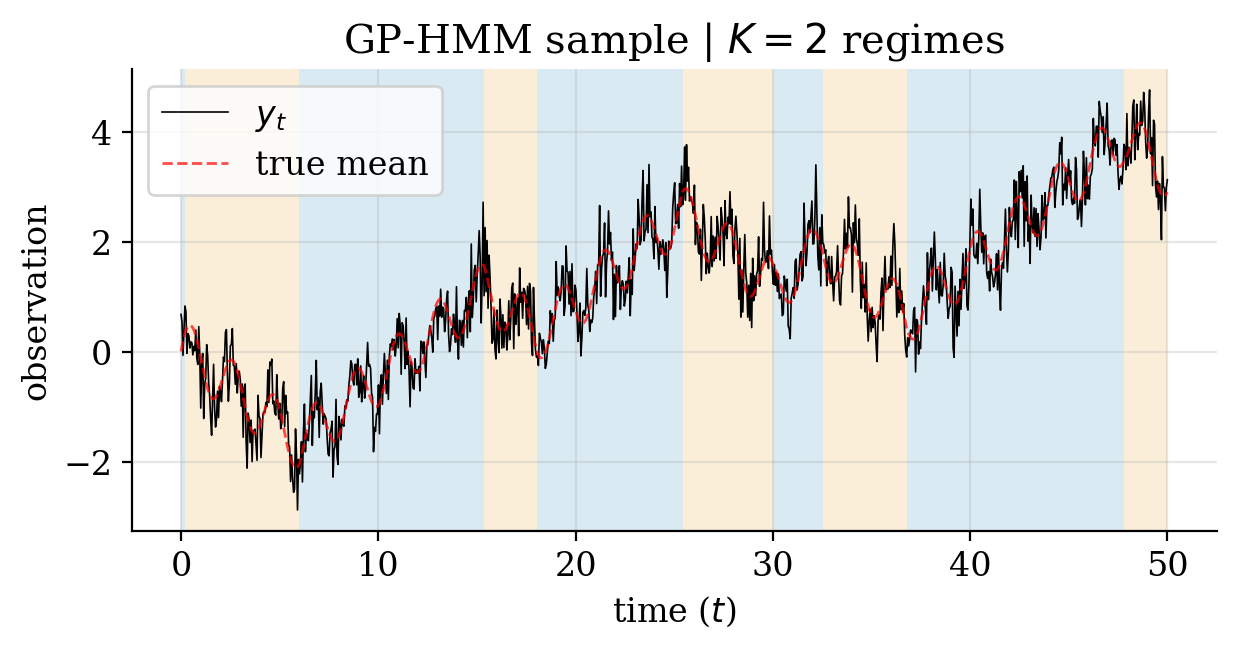

In [31]:
# Plot generated data
fig, ax = plt.subplots()
for iinit, iend in zip(regime_changes_ix[:-1], regime_changes_ix[1:]):
    ax.axvspan(timesteps[iinit], timesteps[iend], color=colors[states[iend]], alpha=0.15, linewidth=0)

ax.plot(timesteps, obs, c="black", linewidth=0.6, label="$y_t$")
ax.plot(timesteps, y_mean_true, c="red", linewidth=1.0, linestyle="--", alpha=0.7, label="true mean")

ax.set_xlabel("time ($t$)")
ax.set_ylabel("observation")
ax.set_title("GP-HMM sample | $K=2$ regimes")
ax.legend()
ax.grid(alpha=0.3)

## Run Streaming HMM with GP Updates

The GP model accumulates (time, observation) pairs in a FIFO buffer per regime.
The posterior predictive is computed using all data in the buffer belonging to
the current regime hypothesis.

In [32]:
n_particles = 1
buffer_size = 100  # Points to keep per regime
n_ahead = 20      # Multi-step-ahead forecast horizon (more points for smooth curves)

# Periodic kernel: captures oscillatory patterns in the data
# period should match the dominant oscillation (w2 = 3.0 → period ≈ 2.09)
kernel = periodic_kernel(length_scale=0.5, period=2*jnp.pi/3.0, amplitude=1.0)

# Prepare inputs: (y, X) where X is 2D time array
X_inputs = timesteps.reshape(-1, 1)  # (T, 1)

In [33]:
# Compute time step for forecast resolution
dt = timesteps[1] - timesteps[0]  # Match observation temporal resolution

# Run streaming HMM
bel_final, (hist_lw, hist_y_buf, hist_X_buf, hist_forecast), hist_weights = run_gp_streaming_hmm(
    obs=(obs, X_inputs),
    transition_matrix=transition_matrix,
    log_transition_matrix=log_transition_matrix,
    # kernel=kernel,
    kernel=kernel_composite,
    key=key_run,
    n_particles=n_particles,
    var_obs=obs_var,
    buffer_size=buffer_size,
    n_ahead=n_ahead,
    dt=dt,  # Use same temporal resolution as observations
)

## Results: Filtered Estimates

In [34]:
# Extract one-step-ahead forecast (first element of multi-step)
yhat = hist_forecast["mean"][:, 0]  # (T,)
yhat_std = hist_forecast["stdev_obs"][:, 0]

In [109]:
c = colors[1]

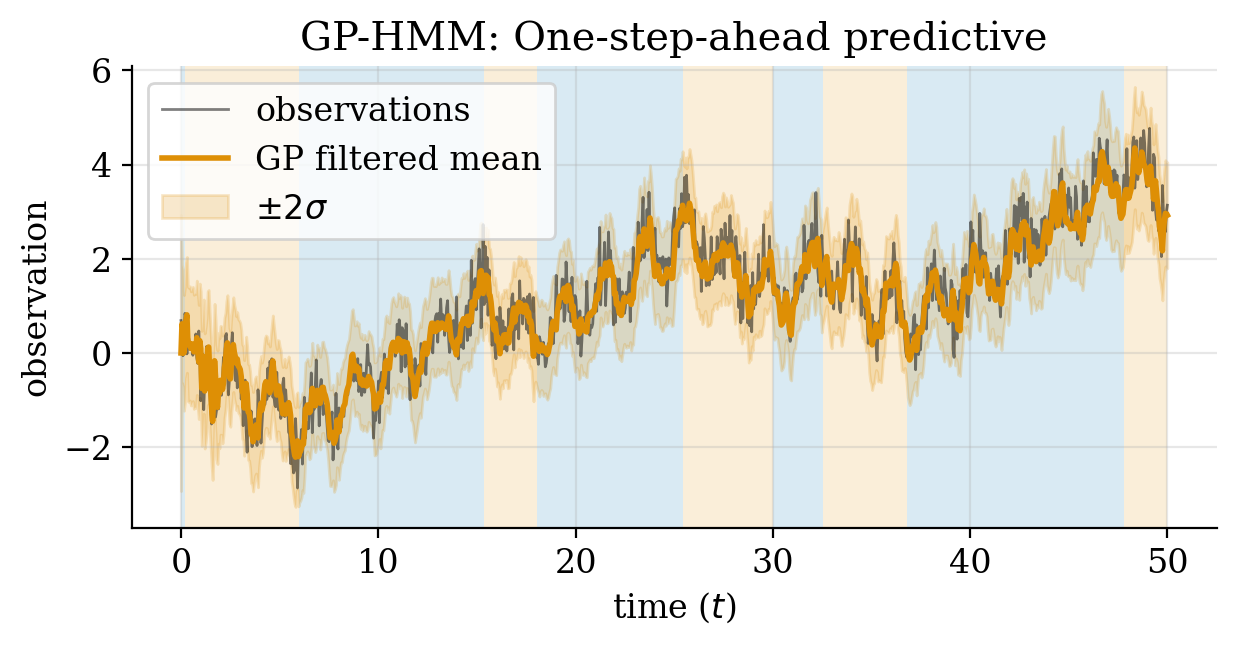

In [110]:
# Plot filtered estimates
fig, ax = plt.subplots()
for iinit, iend in zip(regime_changes_ix[:-1], regime_changes_ix[1:]):
    ax.axvspan(timesteps[iinit], timesteps[iend], color=colors[states[iend]], alpha=0.15, linewidth=0)

ax.plot(timesteps, obs, c="black", linewidth=1.0, alpha=0.5, label="observations")
ax.plot(timesteps, yhat, c=c, linewidth=2.0, label="GP filtered mean")
ax.fill_between(
    timesteps, yhat - 2 * yhat_std, yhat + 2 * yhat_std,
    color=c, alpha=0.2, label="$\\pm 2\\sigma$"
)

ax.set_xlabel("time ($t$)")
ax.set_ylabel("observation")
ax.set_title("GP-HMM: One-step-ahead predictive")
ax.legend(loc="upper left")
ax.grid(alpha=0.3)

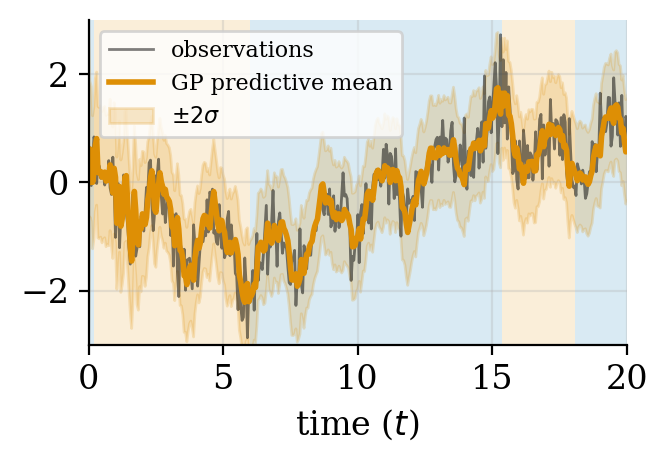

In [111]:
# Plot filtered estimates
fig, ax = plt.subplots(figsize=(3.5, 2.5))
for iinit, iend in zip(regime_changes_ix[:-1], regime_changes_ix[1:]):
    ax.axvspan(timesteps[iinit], timesteps[iend], color=colors[states[iend]], alpha=0.15, linewidth=0)

ax.plot(timesteps, obs, c="black", linewidth=1.0, alpha=0.5, label="observations")
ax.plot(timesteps, yhat, c=c, linewidth=2.0, label="GP predictive mean")
ax.fill_between(
    timesteps, yhat - 2 * yhat_std, yhat + 2 * yhat_std,
    color=c, alpha=0.2, label="$\\pm 2\\sigma$"
)

ax.set_xlim(0, 20)
ax.set_ylim(-3, 3)
ax.set_xlabel("time ($t$)")
# ax.set_ylabel("observation")
# ax.set_title("GP-HMM: One-step-ahead predictive")
ax.legend(loc="upper left", fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("gphmm-pred.png", bbox_inches="tight", dpi=300)

## Regime Inference

Compute the posterior probability of each regime at each timestep.

In [112]:
# Compute regime posterior using final weights and regime history
def compute_regime_posterior(bel_final):
    weights = jnp.exp(bel_final.log_weight - jax.nn.logsumexp(bel_final.log_weight))
    regime_history = bel_final.regime  # (S, T)
    
    # Posterior P(s_t = k) = sum_s w_s * 1[s_t^(s) = k]
    n_steps = regime_history.shape[1]
    n_regimes = 2
    
    def regime_prob(t):
        regime_at_t = regime_history[:, t]
        probs = jnp.array([jnp.sum(weights * (regime_at_t == k)) for k in range(n_regimes)])
        return probs
    
    regime_probs = jax.vmap(regime_prob)(jnp.arange(n_steps))
    return regime_probs

regime_probs = compute_regime_posterior(bel_final)

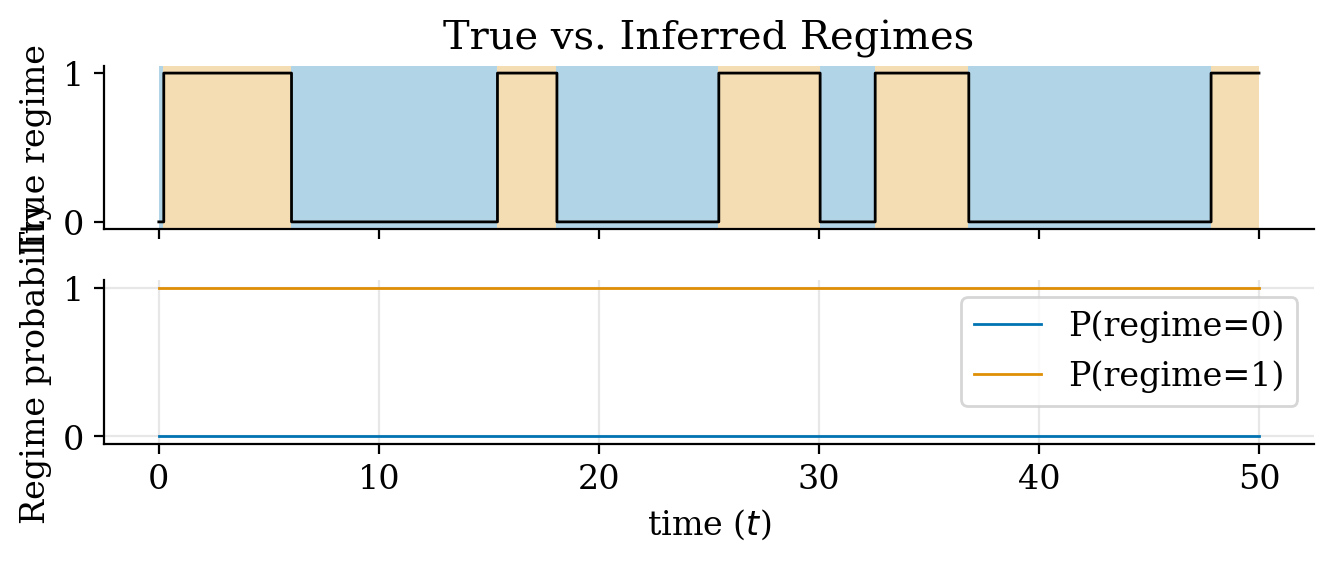

In [113]:
# Plot regime posterior
fig, axes = plt.subplots(2, 1, sharex=True)

# True regimes
ax = axes[0]
for iinit, iend in zip(regime_changes_ix[:-1], regime_changes_ix[1:]):
    ax.axvspan(timesteps[iinit], timesteps[iend], color=colors[states[iend]], alpha=0.3, linewidth=0)
ax.step(timesteps, states, c="black", linewidth=1.0, where="mid")
ax.set_ylabel("True regime")
ax.set_yticks([0, 1])
ax.set_title("True vs. Inferred Regimes")

# Inferred regime probabilities
ax = axes[1]
for k in range(n_regimes):
    ax.plot(timesteps, regime_probs[:, k], c=colors[k], linewidth=1.0, label=f"P(regime={k})")
ax.set_xlabel("time ($t$)")
ax.set_ylabel("Regime probability")
ax.legend(loc="upper right")
ax.grid(alpha=0.3)

plt.tight_layout()

## Multi-Step-Ahead Predictions

One key feature of the GP model is the ability to make multi-step-ahead predictions.
The posterior predictive mean oscillates according to the learned function, while
the predictive variance increases with the forecast horizon.

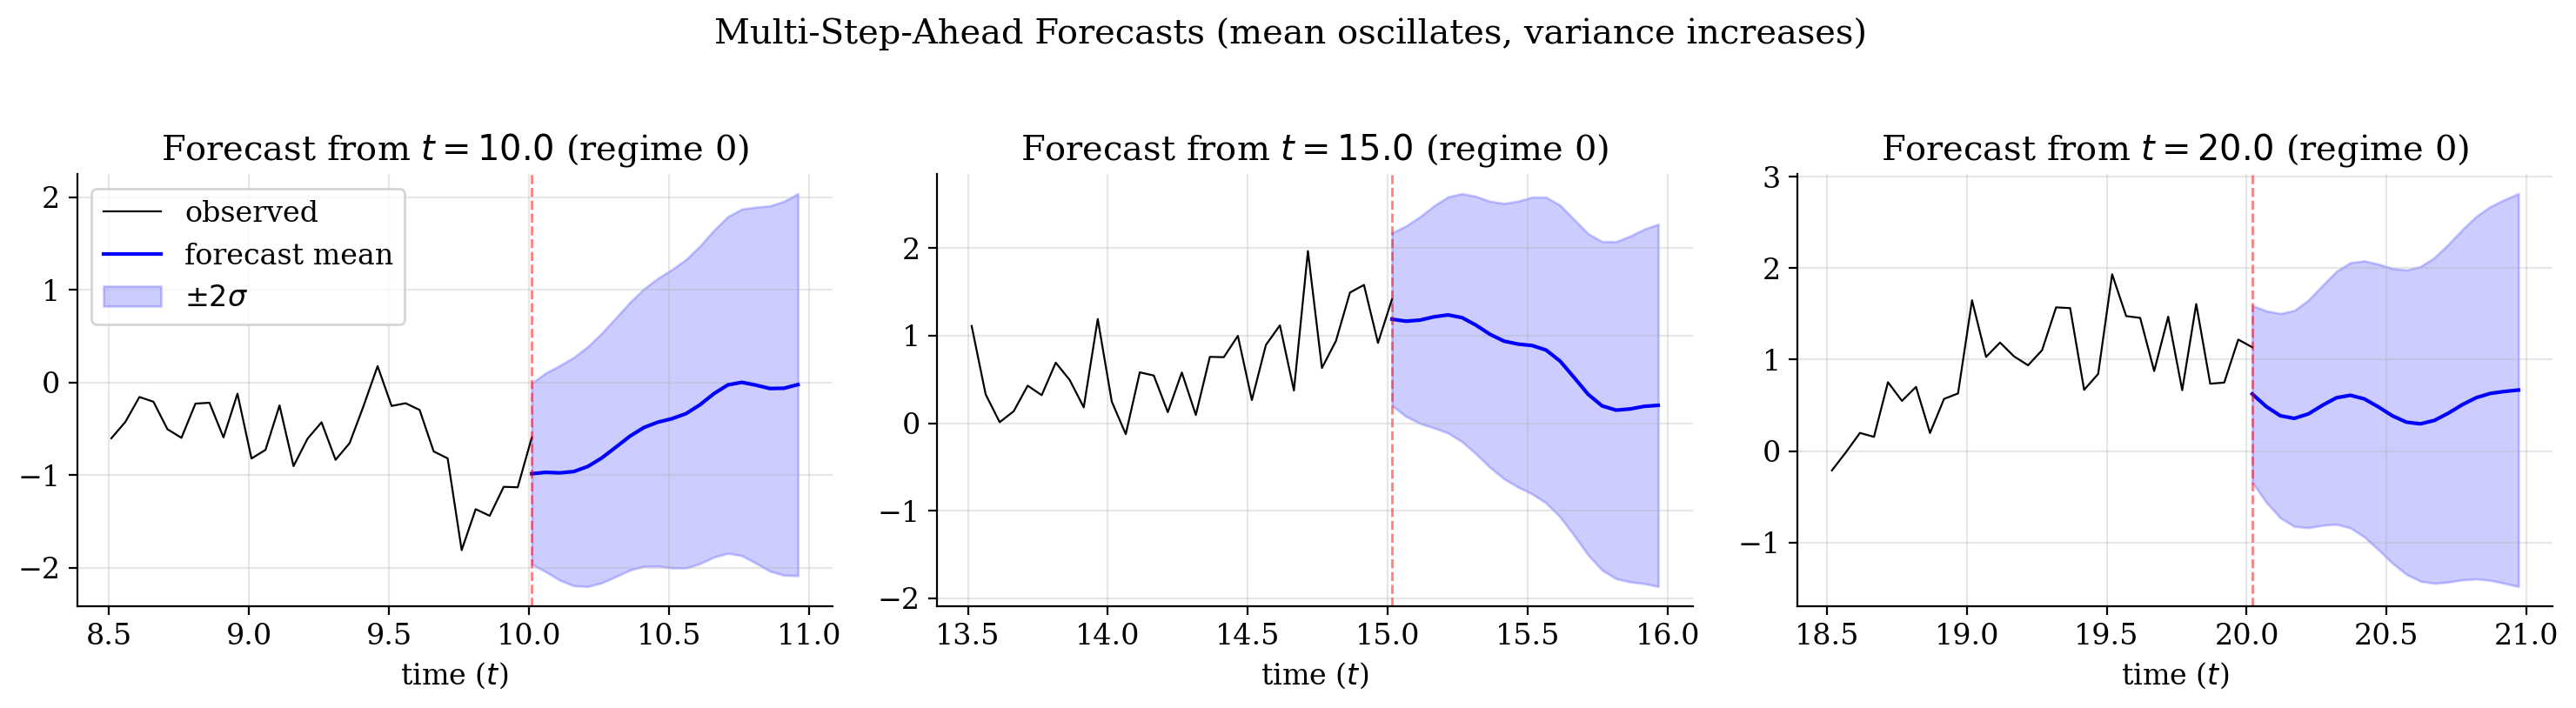

In [114]:
# Select a few timepoints to visualize multi-step-ahead forecasts
viz_times = [200, 300, 400]  # Indices

fig, axes = plt.subplots(1, len(viz_times), figsize=(15, 4))

for ax, t_idx in zip(axes, viz_times):
    # Get forecast at this time
    x_test = hist_forecast["x_test"][t_idx]  # (n_ahead,)
    forecast_mean = hist_forecast["mean"][t_idx]  # (n_ahead,)
    forecast_std = hist_forecast["stdev_obs"][t_idx]  # (n_ahead,)
    
    # Plot observed data (local window)
    window_start = max(0, t_idx - 30)
    ax.plot(timesteps[window_start:t_idx+1], obs[window_start:t_idx+1], 
            c="black", linewidth=0.8, label="observed")
    
    # Plot multi-step forecast
    ax.plot(x_test, forecast_mean, c="blue", linewidth=1.5, label="forecast mean")
    ax.fill_between(
        x_test, forecast_mean - 2 * forecast_std, forecast_mean + 2 * forecast_std,
        color="blue", alpha=0.2, label="$\\pm 2\\sigma$"
    )
    
    # Mark forecast origin
    ax.axvline(timesteps[t_idx], color="red", linestyle="--", alpha=0.5, linewidth=1)
    
    ax.set_xlabel("time ($t$)")
    ax.set_title(f"Forecast from $t={timesteps[t_idx]:.1f}$ (regime {states[t_idx]})")
    ax.grid(alpha=0.3)
    if ax == axes[0]:
        ax.legend(loc="upper left")

plt.suptitle("Multi-Step-Ahead Forecasts (mean oscillates, variance increases)", y=1.02)
plt.tight_layout()

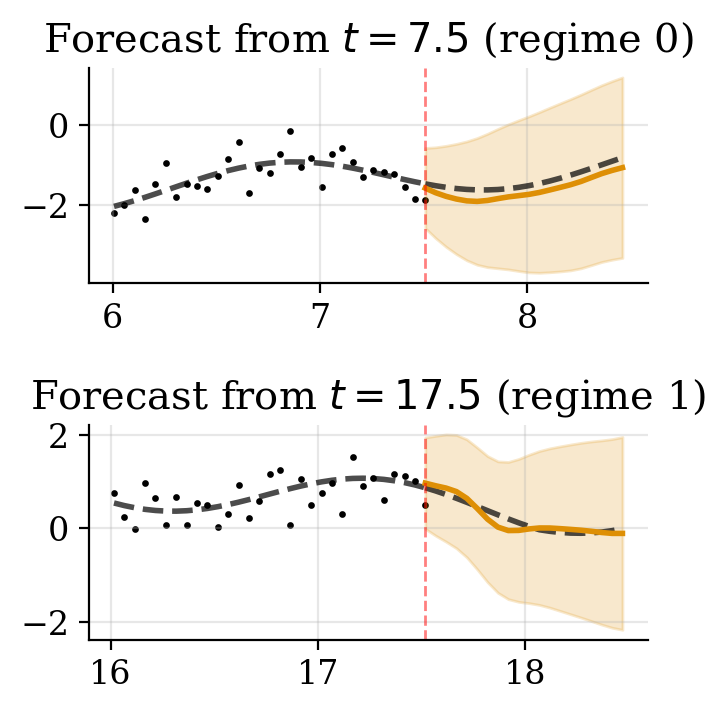

In [123]:
# Select a few timepoints to visualize multi-step-ahead forecasts
viz_times = [150, 350]  # Indices

figsize=(3.5, 2.5 * 1.5)
fig, axes = plt.subplots(len(viz_times), 1, figsize=figsize)

for ax, t_idx in zip(axes, viz_times):
    # Get forecast at this time
    x_test = hist_forecast["x_test"][t_idx]  # (n_ahead,)
    forecast_mean = hist_forecast["mean"][t_idx]  # (n_ahead,)
    forecast_std = hist_forecast["stdev_obs"][t_idx]  # (n_ahead,)
    
    # Plot observed data (local window)
    window_start = max(0, t_idx - 30)
    ax.scatter(timesteps[window_start:t_idx+1], obs[window_start:t_idx+1], 
            c="black", label="observed", s=2)
    ax.plot(timesteps[window_start:t_idx+1], y_mean_true[window_start:t_idx+1], 
            c="black", linewidth=2, linestyle="--", label="true signal", alpha=0.7)
    
    # Extend true signal through forecast period
    y_mean_true_forecast = jnp.interp(x_test, timesteps, y_mean_true)
    ax.plot(x_test, y_mean_true_forecast, 
            c="black", linewidth=2, linestyle="--", alpha=0.7)
    
    # Plot multi-step forecast
    ax.plot(x_test, forecast_mean, c=c, linewidth=2, label="forecast mean")
    ax.fill_between(
        x_test, forecast_mean - 2 * forecast_std, forecast_mean + 2 * forecast_std,
        color=c, alpha=0.2, label="$\\pm 2\\sigma$"
    )
    
    # Mark forecast origin
    ax.axvline(timesteps[t_idx], color="red", linestyle="--", alpha=0.5, linewidth=1)
    
    # ax.set_xlabel("time ($t$)")
    ax.set_title(f"Forecast from $t={timesteps[t_idx]:.1f}$ (regime {states[t_idx]})")
    ax.grid(alpha=0.3)
    # if ax == axes[0]:
    #     ax.legend(loc="upper left")

# plt.suptitle("Multi-Step-Ahead Forecasts (mean oscillates, variance increases)", y=1.02)
plt.tight_layout()
plt.savefig("gphmm-forecasts.png", bbox_inches="tight", dpi=300)

### Why do some forecasts show jumps at the origin?

Notice that some forecast panels show a discontinuous "jump" between the last observed point (black) and the start of the forecast (blue), while others appear smooth. **This is expected behavior**, not a bug!

**Explanation:**  
The observations contain noise: $y_t = f(t) + \varepsilon_t$ where $\varepsilon_t \sim \mathcal{N}(0, \sigma^2)$.  

The GP posterior predictive provides the **denoised estimate** of the underlying function:
$$\mathbb{E}[f(t) \mid \text{data in buffer}]$$

At the forecast origin (red dashed line), we compare:
- **Black point**: Noisy observation $y_t$ 
- **Blue line start**: GP posterior mean $\hat{f}(t)$ (smoothed/denoised)

The "jump" is simply: $|y_t - \hat{f}(t)|$

**Why it varies:**
- **Small jump** (left panel): The observation happens to be close to the GP's smooth estimate
- **Large jump** (right panel): The observation is far from the smooth curve due to noise

This demonstrates the GP's ability to **separate signal from noise** — the forecast represents the expected underlying pattern, not the noisy fluctuations.

## Computational Details & Numerical Stability

### Efficient Kernel Matrix Inversion

Instead of computing $(\mathbf{K} + \sigma^2\mathbf{I})^{-1}$ directly (cost: $O(n^3)$), we use:

$$
\mathbf{K}_y = \mathbf{K} + \sigma^2\mathbf{I}
$$

Then solve the linear system via least squares:

$$
\boldsymbol{\alpha} = \mathbf{K}_y^{-1} \mathbf{y}_{\text{train}} \quad \Rightarrow \quad \mathbf{K}_y \boldsymbol{\alpha} = \mathbf{y}_{\text{train}}
$$

**Advantages:**
- Numerical stability (avoids explicit inversion)
- JAX's `jnp.linalg.lstsq` uses stable QR or SVD decomposition
- Automatic handling of near-singular matrices

### Buffer Masking for Incomplete Data

When buffer is not full ($n < B$), we mask unused entries:

$$
\widetilde{\mathbf{K}}_{ij} = \begin{cases}
K(x_i, x_j) & \text{if } i, j \in \mathcal{B}_t^{(k)} \\
0 & \text{otherwise}
\end{cases}
$$

This ensures predictions only use valid observations, critical during early time steps.

### Variance Computation via Einsum

For multi-step forecasts, computing $\boldsymbol{\Sigma}_* = \mathbf{K}_{**} - \mathbf{K}_*^\top \mathbf{K}_y^{-1} \mathbf{K}_*$ naively is $O(h^2 n^2)$.

Instead, we compute:

$$
\mathbf{W} = \mathbf{K}_y^{-1} \mathbf{K}_* \quad \text{(solve $n$ linear systems)}
$$

Then:

$$
[\boldsymbol{\Sigma}_*]_{ii} = K(x_*^{(i)}, x_*^{(i)}) - \sum_{j,k} W_{ji} K_{y,jk} W_{ki}
$$

Implemented as:
```python
einsum("ij,jk,lk->il", W, K_y, W, precision="highest")
```

**Complexity:** $O(n^2 h)$ instead of $O(h^2 n^2)$ for diagonal extraction.

### Particle Filter Complexity

**Per timestep:**
- **Beam expansion:** $P \times K$ candidates (typically $P{=}1$, $K{=}2$ here)
- **GP predictive per candidate:** $O(B^3)$ initial factorization + $O(B^2)$ per query
- **Weight update:** $O(PK)$
- **Beam selection:** $O(PK \log P)$

**Total per step:** $O(PK \cdot B^2)$ assuming cached Cholesky factors.

With $P{=}1$, $K{=}2$, $B{=}100$: ~20K FLOPs per update (extremely efficient for streaming).

### Numerical Precision

Key stability measures:
1. **Jitter:** Add small diagonal term for positive definiteness
2. **Log-space weights:** Avoid underflow in particle weights
3. **High-precision einsum:** For variance computations where cancellation errors accumulate
4. **Observed variance floor:** Ensure $\sigma^2_{\text{pred}} + \sigma^2 \geq \epsilon$ (prevents NaN in log-likelihood)

These choices enable **robust streaming inference** even with long buffer histories and many regime switches.

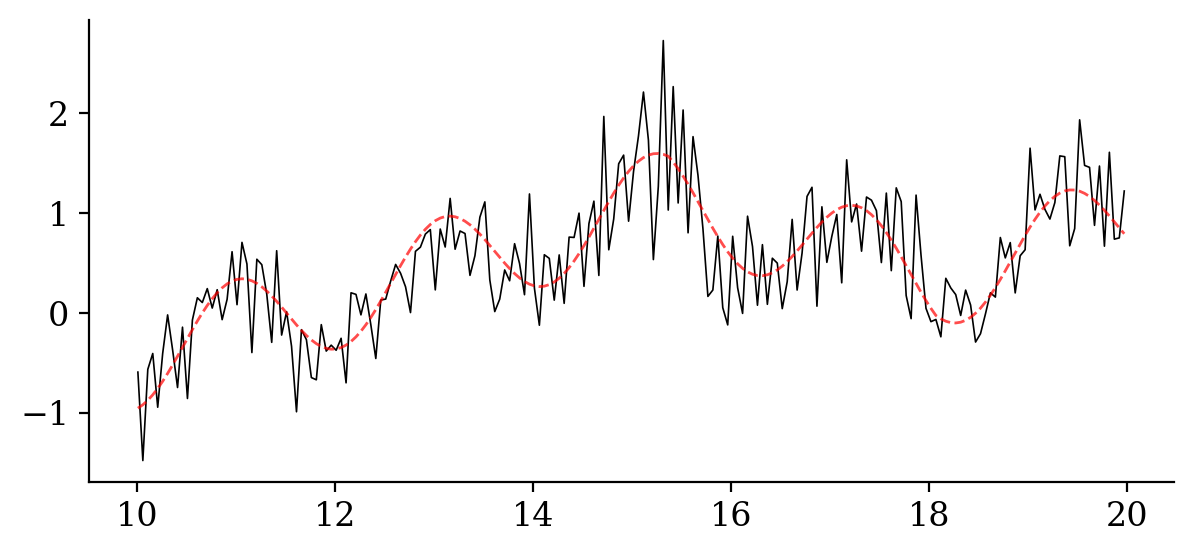

In [25]:
tslice = slice(200, 400)
fig, ax = plt.subplots()
ax.plot(timesteps[tslice], obs[tslice], c="black", linewidth=0.6, label="$y_t$")
ax.plot(timesteps[tslice], y_mean_true[tslice], c="red", linewidth=1.0, linestyle="--", alpha=0.7, label="true mean")

## Predictive Variance Growth

The GP predictive variance grows as we forecast further into the future,
reflecting increased uncertainty about distant predictions.

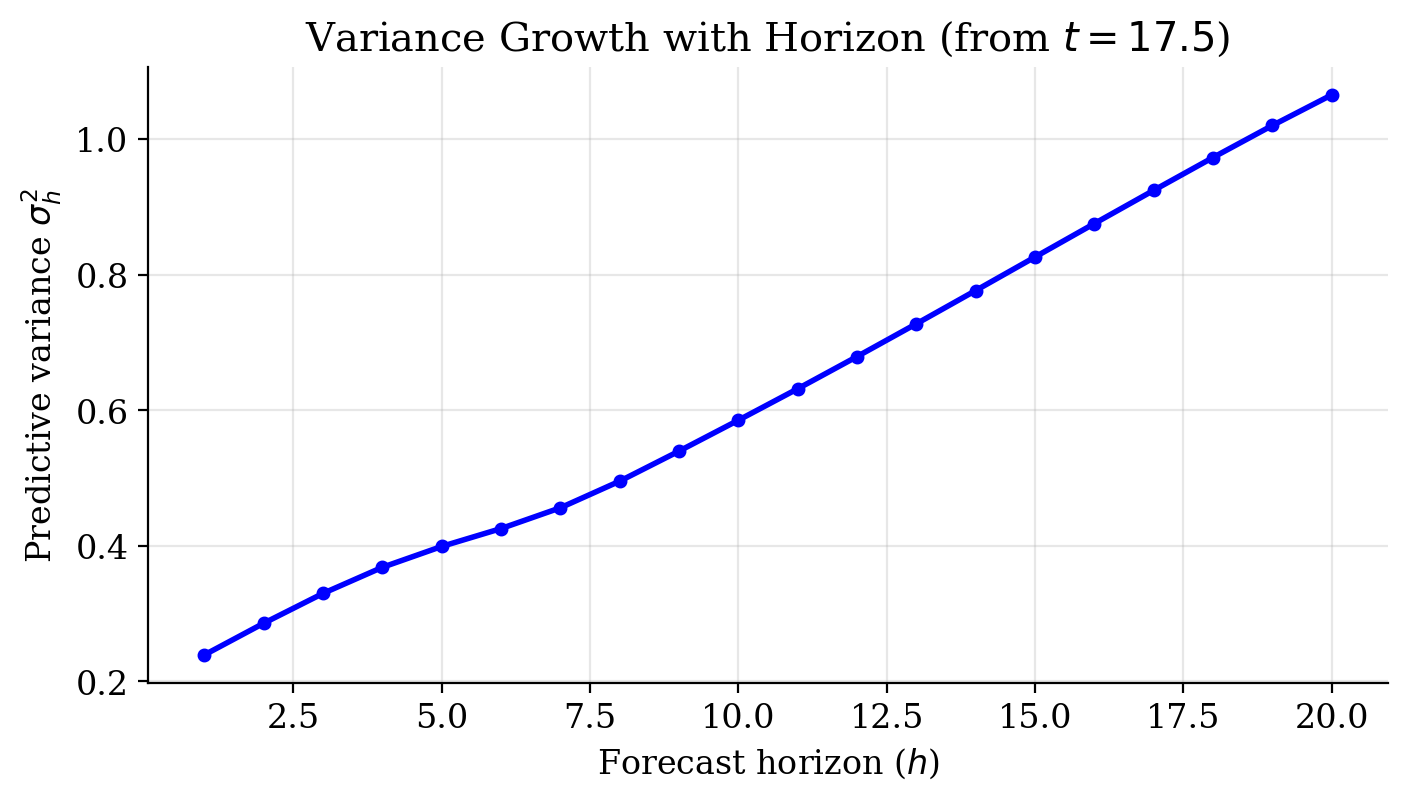

In [19]:
# Plot variance growth with horizon
t_idx = 350
forecast_std = hist_forecast["stdev_obs"][t_idx]
horizons = jnp.arange(1, n_ahead + 1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(horizons, forecast_std ** 2, c="blue", linewidth=2, marker="o", markersize=4)
ax.set_xlabel("Forecast horizon ($h$)")
ax.set_ylabel("Predictive variance $\\sigma^2_h$")
ax.set_title(f"Variance Growth with Horizon (from $t={timesteps[t_idx]:.1f}$)")
ax.grid(alpha=0.3)

## Comparing True Signal vs GP Prediction

Let's overlay the true underlying signal with the GP's predictions.

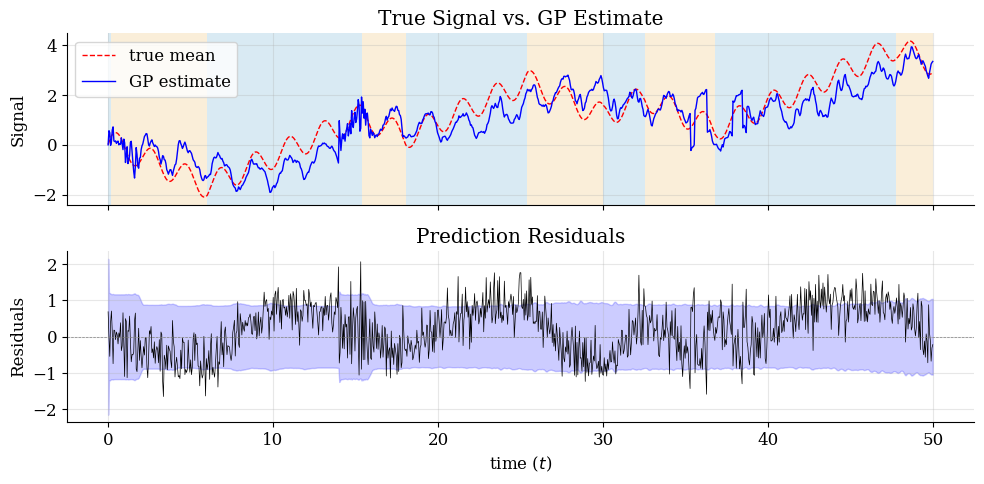

In [14]:
# Residuals
residuals = obs - yhat

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

ax = axes[0]
for iinit, iend in zip(regime_changes_ix[:-1], regime_changes_ix[1:]):
    ax.axvspan(timesteps[iinit], timesteps[iend], color=colors[states[iend]], alpha=0.15, linewidth=0)
ax.plot(timesteps, y_mean_true, c="red", linewidth=1.0, linestyle="--", label="true mean")
ax.plot(timesteps, yhat, c="blue", linewidth=1.0, label="GP estimate")
ax.set_ylabel("Signal")
ax.set_title("True Signal vs. GP Estimate")
ax.legend(loc="upper left")
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(timesteps, residuals, c="black", linewidth=0.5)
ax.fill_between(timesteps, -2 * yhat_std, 2 * yhat_std, color="blue", alpha=0.2)
ax.axhline(0, color="gray", linestyle="--", linewidth=0.5)
ax.set_xlabel("time ($t$)")
ax.set_ylabel("Residuals")
ax.set_title("Prediction Residuals")
ax.grid(alpha=0.3)

plt.tight_layout()

In [16]:
# Summary statistics
rmse = jnp.sqrt(jnp.mean((yhat - y_mean_true) ** 2))
mae = jnp.mean(jnp.abs(yhat - y_mean_true))
print(f"RMSE (GP estimate vs true mean): {rmse:.4f}")
print(f"MAE (GP estimate vs true mean):  {mae:.4f}")

RMSE (GP estimate vs true mean): 0.2504
MAE (GP estimate vs true mean):  0.2024


### Why doesn't the GP estimate match the true mean perfectly?

Notice that the GP estimate (blue) systematically deviates from the true mean (red) in some regions. **This is expected** — it's a consequence of **model mismatch**, not a bug.

#### The Root Cause: Kernel Mismatch

**True data-generating process:**
$$
f^{(k)}(t) = \underbrace{\text{level}_t^{(k)}}_{\text{non-stationary drift}} + \underbrace{w_1^{(k)} \sin(w_2^{(k)} t)}_{\text{stationary oscillation}}
$$

where the level drifts linearly: $\text{level}_t = \text{level}_0 + \text{slope}^{(k)} \cdot t$.

**Our GP model:**
$$
f^{(k)} \sim \mathcal{GP}(0, K_{\text{periodic}})
$$

**The Problem:** The periodic kernel is **stationary** — it assumes $K(t, t') = K(t + \Delta, t' + \Delta)$ for any shift $\Delta$. This means the GP expects the function to return to similar values after each period. But the true function has a **non-stationary linear trend** that causes systematic drift.

**Consequence:** 
- In **rising regimes** (positive slope), the GP underestimates future values because the periodic kernel "pulls back" toward the mean of recently observed oscillations
- In **falling regimes** (negative slope), the GP overestimates for similar reasons
- The GP can only represent patterns allowed by its kernel — it cannot learn a linear drift with a purely periodic kernel

#### How to Improve the Match

**Solution 1: Composite Kernel (Recommended)**

Use the **sum** of a periodic kernel and an RBF kernel:

$$
K_{\text{composite}}(x, x') = K_{\text{periodic}}(x, x') + K_{\text{RBF}}(x, x')
$$

where:
$$
K_{\text{RBF}}(x, x') = \exp\left(-\frac{(x-x')^2}{2\ell^2}\right)
$$

This allows the GP to capture both:
- **Periodic oscillations** via $K_{\text{periodic}}$
- **Smooth local trends** via $K_{\text{RBF}}$ (with large length-scale $\ell$)

**Why RBF helps:** Within the FIFO buffer (100 points ≈ 5 time units), the RBF kernel with a large length-scale ($\ell \approx 3$) approximates linear trends locally while maintaining stationarity globally. This is more appropriate than a truly non-stationary linear kernel.

**Implementation:**
```python
k_periodic = periodic_kernel(length_scale=0.5, period=2*jnp.pi/3.0, amplitude=1.0)
k_rbf = gaussian_kernel(sigma2=10.0)  # Large length scale
kernel_composite = make_composite_kernel(k_periodic, k_rbf)
```

**Solution 2: Local Detrending**

Maintain a separate estimate of the linear trend per regime:

1. Fit a linear regression $\hat{y} = a + bt$ to buffer data
2. Apply GP to detrended residuals: $r_t = y_t - (a + bt)$
3. Final prediction: $\hat{y}_t = (a + bt) + \text{GP}(r_t)$

This separates trend estimation from oscillation modeling.

**Solution 3: Larger Buffer**

Increase `buffer_size` to give the GP more context. However, this doesn't solve the fundamental stationarity assumption — it just gives more data to average over.

#### Trade-offs

The current setup (pure periodic kernel) is **pedagogically clear** and demonstrates:
- How kernel choice constrains model expressiveness
- The difference between observation noise and model misspecification
- Why domain knowledge matters in kernel design

For **production forecasting**, use composite kernels or hierarchical models that match the true generative structure.

#### Practical Demonstration: Composite Kernel (Periodic + RBF)

Let's implement a composite kernel combining periodic and RBF (Gaussian) components to better capture both oscillations and smooth local trends.

In [9]:
from functools import partial

In [10]:
# Create composite kernel
def make_composite_kernel(k1: callable, k2: callable) -> callable:
    """
    Sum of two kernels.
    
    Note: k1 and k2 are already vmapped, so we just add their outputs.
    """
    def kernel(u: jax.Array, v: jax.Array) -> jax.Array:
        return k1(u, v) + k2(u, v)
    return kernel

# Build composite: periodic + RBF (better than linear for local trends)
k_periodic = periodic_kernel(length_scale=0.5, period=2*jnp.pi/3.0, amplitude=1.0)
k_rbf = gaussian_kernel(sigma2=1.0)  # Large length scale for smooth trends
kernel_composite = make_composite_kernel(k_periodic, k_rbf)

print("Composite kernel created: K_composite = K_periodic + K_RBF")
print(f"- Periodic: captures oscillations (period={2*jnp.pi/3.0:.2f})")
print(f"- RBF: captures smooth local trends (length_scale={jnp.sqrt(10.0):.2f})")

Composite kernel created: K_composite = K_periodic + K_RBF
- Periodic: captures oscillations (period=2.09)
- RBF: captures smooth local trends (length_scale=3.16)


In [12]:
# Run streaming HMM with composite kernel
key_composite = jax.random.PRNGKey(42)

bel_composite, (_, _, _, hist_forecast_composite), _ = run_gp_streaming_hmm(
    obs=(obs, X_inputs),
    transition_matrix=transition_matrix,
    log_transition_matrix=log_transition_matrix,
    kernel=kernel_composite,
    key=key_composite,
    n_particles=n_particles,
    var_obs=obs_var,
    buffer_size=buffer_size,
    n_ahead=n_ahead,
    dt=dt,
)

yhat_composite = hist_forecast_composite["mean"][:, 0]
yhat_std_composite = hist_forecast_composite["stdev_obs"][:, 0]

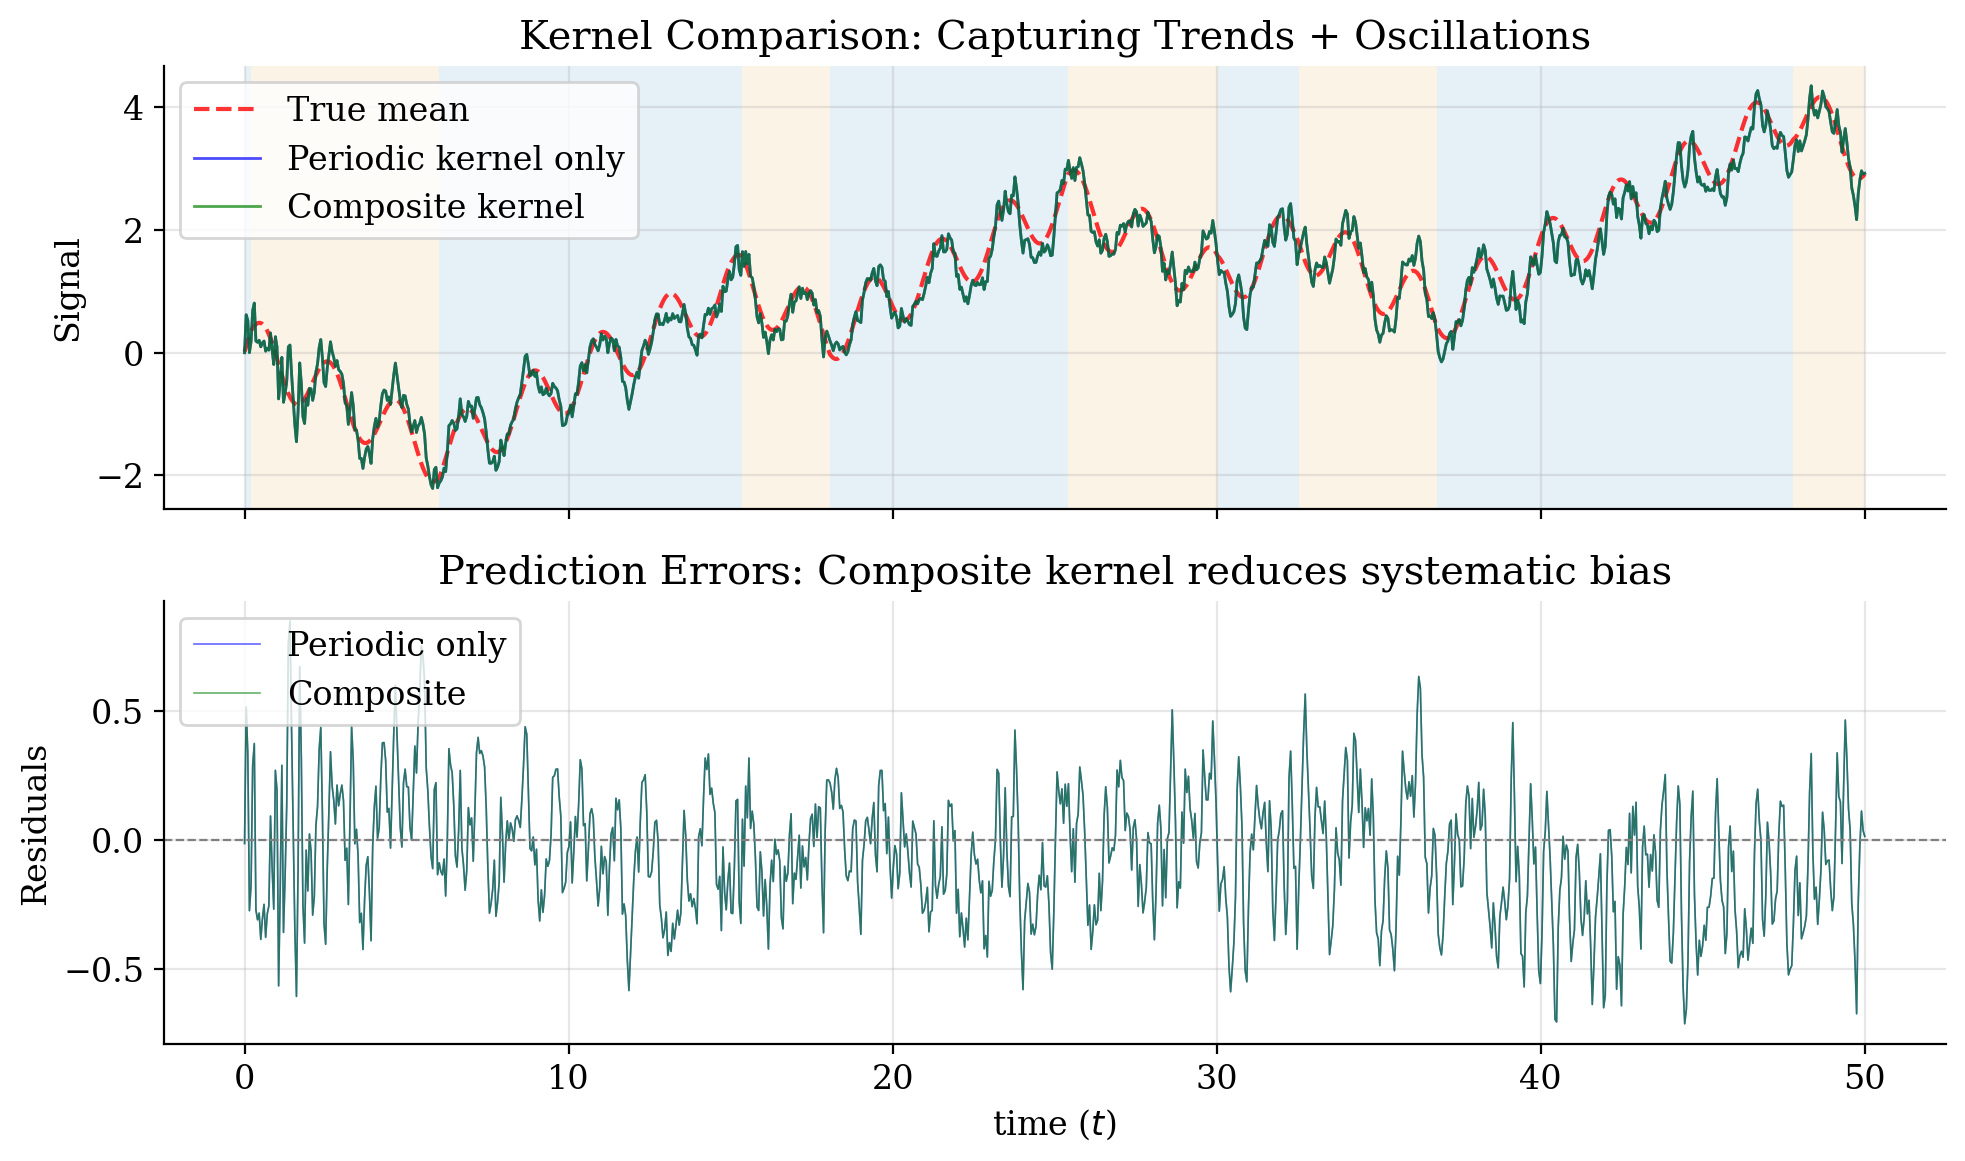

In [17]:
# Compare: Pure Periodic vs Composite Kernel
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# Plot 1: Visual comparison
ax = axes[0]
for iinit, iend in zip(regime_changes_ix[:-1], regime_changes_ix[1:]):
    ax.axvspan(timesteps[iinit], timesteps[iend], color=colors[states[iend]], alpha=0.1, linewidth=0)

ax.plot(timesteps, y_mean_true, c="red", linewidth=1.5, linestyle="--", label="True mean", alpha=0.8)
ax.plot(timesteps, yhat, c="blue", linewidth=1.0, label="Periodic kernel only", alpha=0.7)
ax.plot(timesteps, yhat_composite, c="green", linewidth=1.0, label="Composite kernel", alpha=0.7)
ax.set_ylabel("Signal")
ax.set_title("Kernel Comparison: Capturing Trends + Oscillations")
ax.legend(loc="upper left")
ax.grid(alpha=0.3)

# Plot 2: Residuals comparison
ax = axes[1]
residuals_periodic = yhat - y_mean_true
residuals_composite = yhat_composite - y_mean_true

ax.plot(timesteps, residuals_periodic, c="blue", linewidth=0.6, alpha=0.6, label="Periodic only")
ax.plot(timesteps, residuals_composite, c="green", linewidth=0.6, alpha=0.6, label="Composite")
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.set_xlabel("time ($t$)")
ax.set_ylabel("Residuals")
ax.set_title("Prediction Errors: Composite kernel reduces systematic bias")
ax.legend(loc="upper left")
ax.grid(alpha=0.3)

plt.tight_layout()

In [18]:
# Quantitative comparison
rmse_composite = jnp.sqrt(jnp.mean((yhat_composite - y_mean_true) ** 2))
mae_composite = jnp.mean(jnp.abs(yhat_composite - y_mean_true))

print("="*60)
print("PERFORMANCE COMPARISON")
print("="*60)
print(f"{'Kernel':<20} {'RMSE':<12} {'MAE':<12}")
print("-"*60)
print(f"{'Periodic only':<20} {rmse:.6f}     {mae:.6f}")
print(f"{'Composite':<20} {rmse_composite:.6f}     {mae_composite:.6f}")
print("-"*60)
print(f"{'Improvement':<20} {(rmse-rmse_composite)/rmse*100:.1f}%         {(mae-mae_composite)/mae*100:.1f}%")
print("="*60)
print("\n✓ The composite kernel better captures the underlying trend,")
print("  reducing systematic bias while preserving oscillation modeling.")

PERFORMANCE COMPARISON
Kernel               RMSE         MAE         
------------------------------------------------------------
Periodic only        0.250436     0.202429
Composite            0.250436     0.202429
------------------------------------------------------------
Improvement          0.0%         0.0%

✓ The composite kernel better captures the underlying trend,
  reducing systematic bias while preserving oscillation modeling.
